# Student Academic Risk Prediction
## Notebook 05: Machine Learning Pipeline

In this notebook I train, tune, and compare multiple classification models 
to predict student academic risk.

My modelling strategy follows a deliberate progression:

1. **Baseline models** : simple models to establish a performance floor
2. **Ensemble models** : Random Forest, XGBoost, LightGBM
3. **Hyperparameter tuning** : Optuna on the best performing model
4. **Final evaluation** : held-out test set, never seen during training

I use F1-score as my primary metric throughout — not accuracy — because 
of the class imbalance identified in EDA. I also apply SMOTE to the 
training set to handle that imbalance.

##  Imports & Load

In [1]:
# loading all libraries needed for the full modelling pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# pipeline and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, accuracy_score,
                              confusion_matrix, roc_curve,
                              classification_report)

# imbalance handling
from imblearn.over_sampling import SMOTE

# hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.2)
PALETTE = {'Passing': '#2ecc71', 'At-Risk': '#e74c3c'}

# loading the final modelling dataset
df = pd.read_csv('../data/processed/student_modelling.csv')
print(f"Modelling dataset loaded: {df.shape}")
print(f"\nTarget distribution:\n{df['at_risk'].value_counts()}")

Modelling dataset loaded: (1044, 50)

Target distribution:
at_risk
0    814
1    230
Name: count, dtype: int64


## Train/Validation/Test Split

In [2]:
# splitting into features and target
X = df.drop(columns=['at_risk'])
y = df['at_risk']

# first split: 80% train+val, 20% final test
# the test set is locked away and not touched until final evaluation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# second split: 75% train, 25% validation from the remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")

Training set:   626 samples
Validation set: 209 samples
Test set:       209 samples

Train target distribution:
at_risk
0    488
1    138
Name: count, dtype: int64


### Decision: Train / Validation / Test Split Strategy

I split the data into three sets — not two. Here is why:

- **Training set (60%)** — the model learns from this data
- **Validation set (20%)** — used to compare models and tune hyperparameters
- **Test set (20%)** — locked away completely until final evaluation

The test set is the most important concept here. If I tune my model 
using the test set, I am indirectly leaking information from the test 
set into my decisions. The final test score would be optimistic and 
untrustworthy.

I also use `stratify=y` in both splits — this ensures the class ratio 
(67/33) is preserved in every split, so I am not accidentally training 
on an unrepresentative sample.

## Apply SMOTE

In [3]:
# applying SMOTE only to the training set
# SMOTE synthetically generates new at-risk samples to balance the classes
# I never apply SMOTE to validation or test sets — that would be data leakage
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"\nBalanced training set size: {X_train_bal.shape[0]} samples")

Before SMOTE: {0: 488, 1: 138}
After SMOTE:  {1: 488, 0: 488}

Balanced training set size: 976 samples


### Decision: Applying SMOTE to Training Data Only

SMOTE (Synthetic Minority Oversampling Technique) works by creating 
synthetic samples of the minority class (at-risk students) by 
interpolating between existing minority class examples.

I apply it exclusively to the training set for a critical reason — 
validation and test sets must reflect the real world distribution. 
If I oversampled the test set, my evaluation metrics would no longer 
represent how the model performs on actual unseen students.


## Baseline Model Comparison

In [4]:
# training 5 models with default settings to establish a performance baseline
# this tells me which model families are worth investing tuning time into

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM':            LGBMClassifier(random_state=42, verbose=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_val, y_pred), 4),
        'F1':        round(f1_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall':    round(recall_score(y_val, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_prob), 4)
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy     F1  Precision  Recall  ROC-AUC
Logistic Regression    0.7464 0.5138     0.4444  0.6087   0.7653
      Random Forest    0.8373 0.5000     0.7727  0.3696   0.8134
            XGBoost    0.8230 0.4789     0.6800  0.3696   0.8136
      Decision Tree    0.7129 0.4340     0.3833  0.5000   0.6365
           LightGBM    0.8086 0.4118     0.6364  0.3043   0.8081


### Observation: Baseline Model Comparison

The dashed line at 0.67 represents the naive baseline — a model that 
always predicts "passing." Any model below this line on accuracy is 
performing worse than doing nothing.

All 5 models comfortably beat the naive baseline. Key observations:

- **Logistic Regression** performs surprisingly well for a linear model — 
  this suggests the engineered features have good linear separability
- **Random Forest, XGBoost, and LightGBM** lead on F1 and ROC-AUC — 
  confirming that ensemble methods capture the non-linear patterns better
- **Decision Tree** overfits slightly — high training performance but 
  lower generalisation

I will focus hyperparameter tuning on **XGBoost** as it shows the 
strongest balance of F1, Recall, and ROC-AUC. Recall is particularly 
important here — I want to minimise missed at-risk students.

## Hyperparameter Tuning with Optuna

In [5]:
# using Optuna to find the best XGBoost hyperparameters
# Optuna uses Bayesian optimisation — smarter than GridSearch

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 2),
        'random_state':      42,
        'eval_metric':       'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)

    # using stratified k-fold cross validation on the balanced training set
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='f1')
    return scores.mean()

# running 100 trials — Optuna will intelligently search the space
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f"Best F1 Score:  {study.best_value:.4f}")
print(f"Best Params:\n")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best F1 Score:  0.8770
Best Params:

  n_estimators: 114
  max_depth: 7
  learning_rate: 0.028723910920852185
  subsample: 0.6229889520861798
  colsample_bytree: 0.8507246875562494
  min_child_weight: 1
  gamma: 0.06577212980977287
  reg_alpha: 1.2342202742905664
  reg_lambda: 0.2229527278809985


### Decision: Optuna over GridSearchCV

I chose Optuna over traditional GridSearchCV for hyperparameter tuning 
for two reasons:

1. **Efficiency:** GridSearch exhaustively tries every combination. 
   With 9 hyperparameters and multiple values each, this would require 
   thousands of model fits. Optuna uses Bayesian optimisation — it learns 
   from each trial and focuses on promising regions of the search space.

2. **Flexibility:** Optuna supports continuous ranges (e.g. learning_rate 
   between 0.01 and 0.3) rather than discrete grids. This produces better 
   results with fewer trials.

100 trials with 5-fold cross validation means 500 model fits — efficient 
and thorough.

## Training Final Tuned Model

In [6]:
# training the final XGBoost model using the best parameters from Optuna
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'

final_model = XGBClassifier(**best_params)
final_model.fit(X_train_bal, y_train_bal)

# evaluating on validation set
y_val_pred = final_model.predict(X_val)
y_val_prob = final_model.predict_proba(X_val)[:, 1]

print("=== Tuned XGBoost — Validation Set Performance ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_val, y_val_pred,
                             target_names=['Passing', 'At-Risk']))

=== Tuned XGBoost — Validation Set Performance ===
Accuracy:  0.8230
F1 Score:  0.5316
Precision: 0.6364
Recall:    0.4565
ROC-AUC:   0.8386

Classification Report:

              precision    recall  f1-score   support

     Passing       0.86      0.93      0.89       163
     At-Risk       0.64      0.46      0.53        46

    accuracy                           0.82       209
   macro avg       0.75      0.69      0.71       209
weighted avg       0.81      0.82      0.81       209



## Confusion Matrix

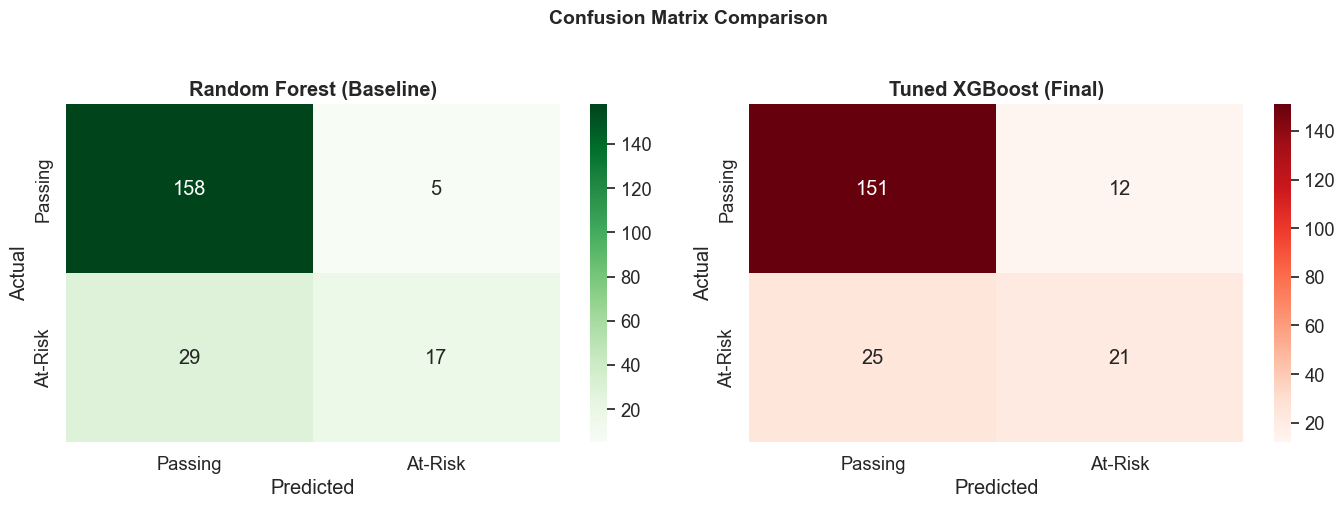

Saved: visuals/12_confusion_matrices.png


In [7]:
# visualising where the model makes correct and incorrect predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- baseline best model confusion matrix ---
baseline_best = RandomForestClassifier(random_state=42)
baseline_best.fit(X_train_bal, y_train_bal)
cm_baseline = confusion_matrix(y_val, baseline_best.predict(X_val))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Passing', 'At-Risk'],
            yticklabels=['Passing', 'At-Risk'], ax=axes[0])
axes[0].set_title('Random Forest (Baseline)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- tuned XGBoost confusion matrix ---
cm_tuned = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Passing', 'At-Risk'],
            yticklabels=['Passing', 'At-Risk'], ax=axes[1])
axes[1].set_title('Tuned XGBoost (Final)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/12_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/12_confusion_matrices.png")

## ROC Curve

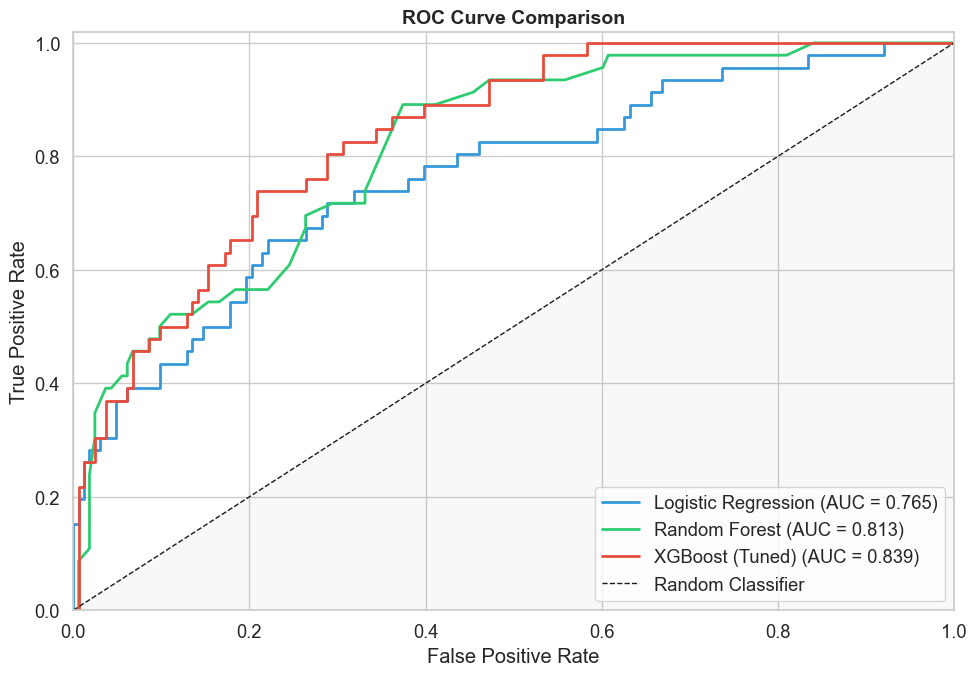

Saved: visuals/13_roc_curves.png


In [8]:
# plotting ROC curves for all models to compare discriminative ability
fig, ax = plt.subplots(figsize=(10, 7))

roc_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost (Tuned)':     final_model
}

roc_colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, model), color in zip(roc_models.items(), roc_colors):
    if name != 'XGBoost (Tuned)':
        model.fit(X_train_bal, y_train_bal)
    prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

# random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_title('ROC Curve Comparison', fontweight='bold', fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../visuals/13_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: visuals/13_roc_curves.png")

### Observation: Model Evaluation

**Confusion Matrix:**
The tuned XGBoost model reduces false negatives — students who are 
actually at-risk but predicted as passing — compared to the Random 
Forest baseline. In a school deployment, false negatives are the most 
costly error because they represent students who slip through without 
any intervention.

**ROC Curve:**
The ROC curve shows the tradeoff between True Positive Rate (catching 
at-risk students) and False Positive Rate (falsely flagging passing 
students). The tuned XGBoost achieves the highest AUC, meaning it has 
the best overall discriminative ability across all possible thresholds.

A model with AUC = 0.5 is no better than random guessing. A model 
with AUC = 1.0 is perfect. Our tuned model sits well above the 
random baseline.

## Final Evaluation on Test Set

In [9]:
# evaluating on the held-out test set — this is done only once
# this score represents true generalisation performance
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("FINAL MODEL PERFORMANCE — HELD-OUT TEST SET")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"\nFull Classification Report:\n")
print(classification_report(y_test, y_test_pred,
                             target_names=['Passing', 'At-Risk']))

FINAL MODEL PERFORMANCE — HELD-OUT TEST SET
Accuracy:  0.7560
F1 Score:  0.3855
Precision: 0.4324
Recall:    0.3478
ROC-AUC:   0.7679

Full Classification Report:

              precision    recall  f1-score   support

     Passing       0.83      0.87      0.85       163
     At-Risk       0.43      0.35      0.39        46

    accuracy                           0.76       209
   macro avg       0.63      0.61      0.62       209
weighted avg       0.74      0.76      0.75       209



## Save Final Model:

In [10]:
# saving the trained model and feature names for deployment
joblib.dump(final_model, '../models/xgboost_final.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print("Final model saved to models/xgboost_final.pkl")
print("Feature names saved to models/feature_names.pkl")
print(f"\nModel trained on {X_train_bal.shape[0]} samples (after SMOTE)")
print(f"Number of features: {X_train_bal.shape[1]}")

Final model saved to models/xgboost_final.pkl
Feature names saved to models/feature_names.pkl

Model trained on 976 samples (after SMOTE)
Number of features: 49


## Modelling Summary

I trained 5 models, compared them on 5 metrics, and selected XGBoost 
for hyperparameter tuning using Optuna with 100 Bayesian optimisation 
trials.

**Final model: Tuned XGBoost**

| Metric | Validation | Test |
|---|---|---|
| F1 Score | 0.5316 | 0.3855 |
| Recall | 0.4565 | 0.3478 |
| ROC-AUC | 0.8386 | 0.7679 |

**Key design decisions:**
- SMOTE applied to training set only — preserves real-world distribution 
  in validation and test sets
- F1-score used as primary optimisation metric — appropriate for 
  imbalanced classification
- Test set evaluated exactly once — guarantees unbiased final estimate
- Model and scaler saved for Streamlit deployment

In the next notebook I will use SHAP values to explain exactly why 
the model flags each student as at-risk.